### 1차 프로젝트(실험) 목표 및 회고
- 이번 프로젝트는 간략하게 말로만 듣던 BERT가 어떻게 구성되는지
- 그리고 어떻게 구현되는지 감을 잡고
- 2차 실험에서 좀 더 다양한 실험을 할 계획이다.

### Step 0. 환경 설정 및 프로젝트 경로 준비
- 필요한 라이브러리 설치
- 기본 import
- seed 고정
- device 확인
- 기존 data / models 경로 연결

In [1]:
# ============================================================
# [STEP 0 - CELL 1] 기본 import / seed 고정 / 경로 설정
# - 재현성을 위해 seed를 고정합니다.
# - 기존 data, models 폴더를 그대로 사용합니다.
# - 새로 저장되는 파일은 모두 mini_ 접두사를 사용합니다.
# ============================================================

from __future__ import absolute_import, division, print_function, unicode_literals

import os
import re
import gc
import math
import json
import copy
import random
import collections
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import matplotlib.pyplot as plt
import sentencepiece as spm


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# ------------------------------------------------------------
# 사용할 파일 경로
# ------------------------------------------------------------
SPM_PREFIX = "models/mini_ko_8000"
SPM_MODEL_PATH = f"{SPM_PREFIX}.model"
SPM_VOCAB_PATH = f"{SPM_PREFIX}.vocab"

PRETRAIN_JSON_PATH = "data/mini_bert_pre_train.json"
MEMMAP_INFO_PATH = "data/mini_pretrain_memmap_info.json"

MINI_CONFIG_PATH = "models/mini_bert_config.json"
MINI_HISTORY_PATH = "models/mini_bert_history.json"
MINI_FINAL_MODEL_PATH = "models/mini_bert_pre_train_final.pt"

# 체크포인트는 epoch별로 따로 저장
def get_checkpoint_path(epoch):
    return f"models/mini_bert_pre_train_epoch_{epoch:02d}.pt"


# ------------------------------------------------------------
# kowiki 코퍼스 위치 찾기
# - 기존에 받은 파일/폴더를 그대로 사용하기 위해 후보 경로를 순서대로 확인합니다.
# ------------------------------------------------------------
candidate_corpus_paths = [
    "kowiki.txt",
    "data/kowiki.txt",
    "D:/PyProject/AIFFEL_AI/LLM/NLP/NLP03/kowiki.txt",
    str(Path.home() / "work" / "bert_pretrain" / "data" / "kowiki.txt"),
]

corpus_file = None
for p in candidate_corpus_paths:
    if os.path.exists(p):
        corpus_file = p
        break

if corpus_file is None:
    raise FileNotFoundError(
        "kowiki.txt를 찾지 못했습니다. 현재 폴더, data 폴더, 또는 기존 작업 경로에 파일이 있는지 확인해주세요."
    )

print("corpus_file:", corpus_file)
print("SPM_MODEL_PATH:", SPM_MODEL_PATH)
print("PRETRAIN_JSON_PATH:", PRETRAIN_JSON_PATH)

device: cuda
corpus_file: kowiki.txt
SPM_MODEL_PATH: models/mini_ko_8000.model
PRETRAIN_JSON_PATH: data/mini_bert_pre_train.json


### Step 1. SentencePiece 토크나이저 준비
- vocab size 8000 설정
- BERT 특수 토큰 포함
- SentencePiece 모델 학습 또는 기존 모델 로드
- vocab 및 special token 확인

In [4]:
# ============================================================
# [STEP 1 - CELL 1] SentencePiece 모델 학습 또는 로드
# - vocab_size=8000으로 mini-BERT용 토크나이저를 준비합니다.
# - BERT 주요 특수 토큰 [PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK]를 포함합니다.
# - 이미 mini 모델이 있으면 재학습하지 않고 그대로 로드합니다.
# ============================================================

if not os.path.exists(SPM_MODEL_PATH):
    print("mini SentencePiece 모델이 없어서 새로 학습합니다.")

    spm.SentencePieceTrainer.train(
        f"--input={corpus_file} "
        f"--model_prefix={SPM_PREFIX} "
        f"--vocab_size=8000 "
        f"--model_type=bpe "
        f"--max_sentence_length=999999 "
        f"--pad_id=0 --pad_piece=[PAD] "
        f"--unk_id=1 --unk_piece=[UNK] "
        f"--bos_id=2 --bos_piece=[BOS] "
        f"--eos_id=3 --eos_piece=[EOS] "
        f"--user_defined_symbols=[SEP],[CLS],[MASK]"
    )
    print("mini SentencePiece 학습 완료")
else:
    print("기존 mini SentencePiece 모델을 그대로 사용합니다.")

vocab = spm.SentencePieceProcessor()
vocab.load(SPM_MODEL_PATH)

print("vocab size:", vocab.get_piece_size())
for i in range(7):
    print(i, "->", vocab.id_to_piece(i))

mini SentencePiece 모델이 없어서 새로 학습합니다.
mini SentencePiece 학습 완료
vocab size: 8000
0 -> [PAD]
1 -> [UNK]
2 -> [BOS]
3 -> [EOS]
4 -> [SEP]
5 -> [CLS]
6 -> [MASK]


In [5]:
# ============================================================
# [STEP 1 - CELL 2] vocab_list 준비 및 특수 토큰 확인
# - random token 치환용 vocab_list를 생성합니다.
# - 특수 토큰 7개는 제외합니다.
# ============================================================

vocab_list = []
for idx in range(7, vocab.get_piece_size()):
    if not vocab.is_unknown(idx):
        vocab_list.append(vocab.id_to_piece(idx))

print("usable vocab size (excluding 7 specials):", len(vocab_list))
print("sample pieces:", vocab_list[:30])

PAD_ID  = vocab.piece_to_id("[PAD]")
UNK_ID  = vocab.piece_to_id("[UNK]")
BOS_ID  = vocab.piece_to_id("[BOS]")
EOS_ID  = vocab.piece_to_id("[EOS]")
SEP_ID  = vocab.piece_to_id("[SEP]")
CLS_ID  = vocab.piece_to_id("[CLS]")
MASK_ID = vocab.piece_to_id("[MASK]")

print("PAD_ID :", PAD_ID)
print("UNK_ID :", UNK_ID)
print("SEP_ID :", SEP_ID)
print("CLS_ID :", CLS_ID)
print("MASK_ID:", MASK_ID)

usable vocab size (excluding 7 specials): 7993
sample pieces: ['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정']
PAD_ID : 0
UNK_ID : 1
SEP_ID : 4
CLS_ID : 5
MASK_ID: 6


### Step 2. MLM용 Mask 생성 함수 구현
- 15% masking 규칙 반영
- 80% [MASK], 10% 랜덤 토큰, 10% 원본 유지
- special token 제외 처리

In [6]:
# ============================================================
# [STEP 2 - CELL 1] MLM용 mask 생성 함수
# - 기존 파일의 create_pretrain_mask() 이름과 흐름을 유지합니다.
# - 전체 토큰의 약 15%를 대상으로 하며,
#   80%는 [MASK], 10%는 random token, 10%는 원본 유지 규칙을 적용합니다.
# - [CLS], [SEP]는 마스킹 대상에서 제외합니다.
# ============================================================

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue

        # SentencePiece에서 ▁ 로 시작하지 않으면 같은 단어의 이어지는 subword로 처리
        if 0 < len(cand_idx) and not token.startswith("\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = random.random()

        for index in index_set:
            masked_token = None

            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### Step 3. NSP Pair 생성 및 시퀀스 구성
- 문장 A/B pair 생성
- 50% True / 50% False NSP 구성
- [CLS], [SEP] 삽입
- segment id 생성
- 시퀀스 길이 조정

In [7]:
# ============================================================
# [STEP 3 - CELL 1] NSP pair 생성을 위한 보조 함수
# - 기존 파일의 trim_tokens() 이름을 유지합니다.
# - 두 문장 길이 합이 max_seq를 넘지 않도록 자릅니다.
# ============================================================

def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [8]:
# ============================================================
# [STEP 3 - CELL 2] NSP + MLM 인스턴스 생성 함수
# - 기존 파일의 create_pretrain_instances() 이름을 유지합니다.
# - 50%는 실제 다음 문장(is_next=1), 50%는 랜덤 문장(is_next=0)으로 구성합니다.
# - [CLS] A [SEP] B [SEP] 구조와 segment 정보를 함께 만듭니다.
# - 이후 MLM mask 정보(mask_idx, mask_label)도 함께 저장합니다.
# ============================================================

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP]

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            is_next = 0

            # 50% 확률로 실제 다음 문장 / 랜덤 문장 결정
            if len(current_chunk) == 1 or random.random() < 0.5:
                is_next = 0
                random_doc_idx = random.randrange(len(doc))
                tokens_b = doc[random_doc_idx].copy()
            else:
                is_next = 1
                for j in range(a_end, len(current_chunk)):
                    tokens_b.extend(current_chunk[j])

            trim_tokens(tokens_a, tokens_b, max_seq)

            if len(tokens_a) < 1 or len(tokens_b) < 1:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens_masked, mask_idx, mask_label = create_pretrain_mask(copy.deepcopy(tokens), mask_cnt, vocab_list)

            instance = {
                "tokens": tokens_masked,
                "segment": segment,
                "is_next": int(is_next),
                "mask_idx": mask_idx,
                "mask_label": mask_label,
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

### Step 4. BERT Pretrain용 JSON 데이터셋 생성
- 문서 단위 코퍼스 처리
- MLM + NSP가 반영된 pretrain instance 생성
- mini_bert_pre_train.json 저장

In [9]:
# ============================================================
# [STEP 4 - CELL 1] 전체 pretrain json 생성 함수
# - 기존 파일의 make_pretrain_data() 이름을 유지합니다.
# - 문서 단위로 읽어서 NSP/MLM 인스턴스를 만들고 json line 형식으로 저장합니다.
# - 기존 데이터는 그대로 두고 mini_bert_pre_train.json으로 저장합니다.
# ============================================================

def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    vocab_list = []
    for idx in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(idx):
            vocab_list.append(vocab.id_to_piece(idx))

    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    with open(out_file, "w", encoding="utf-8") as out_f:
        with open(in_file, "r", encoding="utf-8") as in_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt, desc="make_pretrain_data"):
                line = line.strip()

                if line == "":
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if len(pieces) > 0:
                        doc.append(pieces)

            if 0 < len(doc):
                save_pretrain_instances(out_f, doc)

    print("pretrain json saved to:", out_file)

In [10]:
# ============================================================
# [STEP 4 - CELL 2] mini pretrain json 생성
# - 이미 생성된 mini json이 있으면 재생성하지 않습니다.
# - 처음 실행 시 시간이 걸릴 수 있습니다.
# ============================================================

N_SEQ = 128
MASK_PROB = 0.15

if not os.path.exists(PRETRAIN_JSON_PATH):
    make_pretrain_data(vocab, corpus_file, PRETRAIN_JSON_PATH, N_SEQ, mask_prob=MASK_PROB)
else:
    print("기존 mini pretrain json을 그대로 사용합니다:", PRETRAIN_JSON_PATH)

# 라인 수 확인
total_json_lines = 0
with open(PRETRAIN_JSON_PATH, "r", encoding="utf-8") as f:
    for _ in f:
        total_json_lines += 1

print("total pretrain instances:", total_json_lines)

make_pretrain_data: 100%|█████████████████████████████████████████████████| 3957761/3957761 [04:17<00:00, 15390.72it/s]


pretrain json saved to: data/mini_bert_pre_train.json
total pretrain instances: 918198


### Step 5. np.memmap 기반 학습 데이터셋 구성
- json → memmap 변환
- input_ids, segment_ids, NSP label, MLM label 저장
- 메모리 사용 최소화
- 학습용 데이터 로드

In [11]:
# ============================================================
# [STEP 5 - CELL 1] pretrain json -> memmap 변환 함수
# - 메모리 절약을 위해 np.memmap을 사용합니다.
# - enc_tokens / segments / labels_nsp / labels_mlm을 저장합니다.
# - 모든 출력 파일은 mini_ 접두사를 사용합니다.
# ============================================================

def build_pretrain_memmap(vocab, json_path, n_seq, info_path):
    with open(json_path, "r", encoding="utf-8") as f:
        total = sum(1 for _ in f)

    enc_path = "data/mini_enc_tokens.memmap"
    seg_path = "data/mini_segments.memmap"
    nsp_path = "data/mini_labels_nsp.memmap"
    mlm_path = "data/mini_labels_mlm.memmap"

    enc_tokens = np.memmap(enc_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(seg_path, mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(nsp_path, mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(mlm_path, mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(json_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="build_pretrain_memmap")):
            data = json.loads(line)

            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [PAD_ID] * (n_seq - len(enc_token))

            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))

            label_nsp = int(data["is_next"])

            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, fill_value=PAD_ID, dtype=np.int32)
            label_mlm[mask_idx] = mask_label

            enc_tokens[i] = np.array(enc_token, dtype=np.int32)
            segments[i] = np.array(segment, dtype=np.int32)
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    enc_tokens.flush()
    segments.flush()
    labels_nsp.flush()
    labels_mlm.flush()

    info = {
        "total": total,
        "n_seq": n_seq,
        "enc_path": enc_path,
        "seg_path": seg_path,
        "nsp_path": nsp_path,
        "mlm_path": mlm_path,
        "dtype": "int32",
    }

    with open(info_path, "w", encoding="utf-8") as f:
        json.dump(info, f, ensure_ascii=False, indent=2)

    print("memmap info saved to:", info_path)
    return info

In [12]:
# ============================================================
# [STEP 5 - CELL 2] mini memmap 생성
# - 이미 memmap 정보 파일이 있으면 다시 만들지 않습니다.
# ============================================================

if not os.path.exists(MEMMAP_INFO_PATH):
    memmap_info = build_pretrain_memmap(vocab, PRETRAIN_JSON_PATH, N_SEQ, MEMMAP_INFO_PATH)
else:
    with open(MEMMAP_INFO_PATH, "r", encoding="utf-8") as f:
        memmap_info = json.load(f)
    print("기존 mini memmap 정보를 그대로 사용합니다.")

print(memmap_info)

build_pretrain_memmap: 100%|█████████████████████████████████████████████████| 918198/918198 [01:34<00:00, 9704.05it/s]


memmap info saved to: data/mini_pretrain_memmap_info.json
{'total': 918198, 'n_seq': 128, 'enc_path': 'data/mini_enc_tokens.memmap', 'seg_path': 'data/mini_segments.memmap', 'nsp_path': 'data/mini_labels_nsp.memmap', 'mlm_path': 'data/mini_labels_mlm.memmap', 'dtype': 'int32'}


In [13]:
# ============================================================
# [STEP 5 - CELL 3] 학습용 데이터 로드 함수
# - 기존 파일의 load_pre_train_data() 이름을 유지합니다.
# - memmap을 읽어 필요한 개수만 메모리로 로딩할 수 있게 구성합니다.
# ============================================================

def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드

    :param vocab: vocab
    :param filename: memmap info json 파일
    :param n_seq: 시퀀스 길이
    :param count: 데이터 수 제한 (None이면 전체)

    :return (enc_tokens, segments), (labels_nsp, labels_mlm)
    """
    with open(filename, "r", encoding="utf-8") as f:
        info = json.load(f)

    total = info["total"]
    use_count = total if count is None else min(count, total)

    enc_tokens = np.memmap(info["enc_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count]
    segments = np.memmap(info["seg_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count]
    labels_nsp = np.memmap(info["nsp_path"], mode="r", dtype=np.int32, shape=(total,))[:use_count]
    labels_mlm = np.memmap(info["mlm_path"], mode="r", dtype=np.int32, shape=(total, n_seq))[:use_count]

    # 학습 안정성을 위해 실제 numpy array로 복사
    enc_tokens = np.array(enc_tokens, dtype=np.int64)
    segments = np.array(segments, dtype=np.int64)
    labels_nsp = np.array(labels_nsp, dtype=np.int64)
    labels_mlm = np.array(labels_mlm, dtype=np.int64)

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [14]:
# ============================================================
# [STEP 5 - CELL 4] pretrain 데이터 로드
# - 너무 큰 경우 count를 줄여 먼저 테스트할 수 있습니다.
# - 최종 제출은 count=None으로 전체 사용을 권장합니다.
# ============================================================

# 필요 시 예: count=128000
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab=vocab,
    filename=MEMMAP_INFO_PATH,
    n_seq=N_SEQ,
    count=None
)

print("enc_tokens shape:", pre_train_inputs[0].shape)
print("segments   shape:", pre_train_inputs[1].shape)
print("labels_nsp shape:", pre_train_labels[0].shape)
print("labels_mlm shape:", pre_train_labels[1].shape)

enc_tokens shape: (918198, 128)
segments   shape: (918198, 128)
labels_nsp shape: (918198,)
labels_mlm shape: (918198, 128)


### Step 6. mini-BERT 설정값 및 공통 유틸리티 정의
- pad mask / ahead mask 함수
- gelu activation
- initializer 함수
- Config 클래스
- mini-BERT config 저장 및 로드

In [15]:
# ============================================================
# [STEP 6 - CELL 1] pad mask / ahead mask / gelu / initializer / Config
# - 기존 파일의 함수/클래스 이름을 그대로 유지합니다.
# - BERT pretrain에 필요한 기초 유틸리티를 정의합니다.
# ============================================================

def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: attention에서 masking할 형태
    """
    mask = tokens.eq(i_pad).unsqueeze(1).unsqueeze(2)  # (bs, 1, 1, n_seq)
    return mask


def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq), device=tokens.device))
    ahead_mask = ahead_mask.bool().unsqueeze(0).unsqueeze(1)  # (1,1,n_seq,n_seq)
    pad_mask = get_pad_mask(tokens, i_pad)
    return ahead_mask | pad_mask


def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))


def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_


def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_


class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r', encoding='utf-8') as f:
            config = json.loads(f.read())
            return Config(config)

In [22]:
# ============================================================
# [STEP 6 - CELL 2] mini-BERT config 정의 및 저장
# - 약 1M 파라미터 규모를 목표로 한 mini 설정입니다.
# - 함수/클래스는 그대로 두고 숫자만 mini 규모로 줄입니다.
# ============================================================

mini_config_dict = {
    "d_model": 96,
    "n_head": 4,
    "d_head": 24,              # 4 * 24 = 96
    "dropout": 0.1,
    "d_ff": 192,
    "layernorm_epsilon": 1e-12,
    "n_layer": 3,
    "n_seq": N_SEQ,
    "n_vocab": vocab.get_piece_size(),
    "i_pad": PAD_ID
}

with open(MINI_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(mini_config_dict, f, ensure_ascii=False, indent=2)

config = Config.load(MINI_CONFIG_PATH)
print(config)

{'d_model': 96, 'n_head': 4, 'd_head': 24, 'dropout': 0.1, 'd_ff': 192, 'layernorm_epsilon': 1e-12, 'n_layer': 3, 'n_seq': 128, 'n_vocab': 8000, 'i_pad': 0}


### Step 7. mini-BERT 모델 구현
- Embedding 레이어 구현
- Multi-Head Attention / Feed Forward / Encoder Layer 구현
- BERT 본체 구현
- PreTrainModel 구현
- 파라미터 수 확인

In [23]:
# ============================================================
# [STEP 7 - CELL 1] Embedding / Attention / Encoder / BERT / PreTrainModel
# - 기존 파일의 클래스 이름을 그대로 유지합니다.
# - 다만 학습 안정성을 위해 forward 내부 구현은 올바른 형태로 정리했습니다.
# - PreTrainModel은 CrossEntropyLoss를 위해 softmax 이전의 raw logits를 반환합니다.
# ============================================================

class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return F.embedding(inputs, self.shared_weights)
        elif mode == "linear":
            return torch.matmul(inputs, self.shared_weights.t())
        else:
            raise ValueError("mode should be 'embedding' or 'linear'")


class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        batch_size, seq_len = inputs.size()
        positions = torch.arange(seq_len, device=inputs.device).unsqueeze(0).expand(batch_size, seq_len)
        return self.embedding(positions)


class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        d_head = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-1, -2)) / math.sqrt(d_head)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, -1e9)

        attn_prob = F.softmax(scores, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out


class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.linear = nn.Linear(config.n_head * config.d_head, config.d_model)

        self.attention = ScaleDotProductAttention()
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.size(0)

        q_s = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        k_s = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        v_s = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        if attn_mask is not None:
            attn_mask = attn_mask.expand(batch_size, self.n_head, Q.size(1), K.size(1))

        attn_out = self.attention(q_s, k_s, v_s, attn_mask)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, -1, self.n_head * self.d_head)
        output = self.linear(attn_out)
        return self.dropout(output)


class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, inputs):
        ff_val = self.W_2(self.dropout(gelu(self.W_1(inputs))))
        return ff_val


class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out


class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )

        self.dropout = nn.Dropout(config.dropout)

        # NSP용 CLS projection
        self.pooler = nn.Linear(config.d_model, config.d_model)

    def get_embedding(self, enc_tokens, segments):
        token_emb = self.embedding(enc_tokens, mode="embedding")
        pos_emb = self.position(enc_tokens)
        seg_emb = self.segment(segments)
        return self.norm(token_emb + pos_emb + seg_emb)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = torch.tanh(self.pooler(enc_out[:, 0]))   # (bs, d_model)
        logits_lm = self.embedding(enc_out, mode="linear")    # (bs, n_seq, n_vocab)

        return logits_cls, logits_lm


class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs


class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        outputs_nsp = self.pooled_output(logits_cls)  # raw logits
        outputs_mlm = logits_lm                       # raw logits
        return outputs_nsp, outputs_mlm


def build_model_pre_train(config):
    return PreTrainModel(config)

In [24]:
# ============================================================
# [STEP 7 - CELL 2] mini-BERT 모델 생성 및 파라미터 수 확인
# - 제출 루브릭에 맞게 약 1M 규모인지 확인합니다.
# - torchinfo summary도 함께 출력합니다.
# ============================================================

pre_train_model = build_model_pre_train(config).to(device)

total_params = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)

print(f"total params    : {total_params:,}")
print(f"trainable params: {trainable_params:,}")

enc_tokens_example = torch.randint(0, config.n_vocab, (2, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (2, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, input_data=[enc_tokens_example, segments_example], depth=3)

total params    : 1,023,842
trainable params: 1,023,842


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [2, 2]                    --
├─BERT: 1-1                                                  [2, 96]                   --
│    └─SharedEmbedding: 2-1                                  [2, 128, 96]              768,000
│    └─PositionEmbedding: 2-2                                [2, 128, 96]              --
│    │    └─Embedding: 3-1                                   [2, 128, 96]              12,288
│    └─Embedding: 2-3                                        [2, 128, 96]              192
│    └─LayerNorm: 2-4                                        [2, 128, 96]              192
│    └─Dropout: 2-5                                          [2, 128, 96]              --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [2, 128, 96]           

### Step 8. Loss, Accuracy, Optimizer, Scheduler 준비
- MLM loss / accuracy 정의
- NSP loss 정의
- DataLoader 구성
- AdamW optimizer 및 cosine scheduler 설정

In [25]:
# ============================================================
# [STEP 8 - CELL 1] MLM loss / MLM accuracy / LR scheduler 정의
# - 기존 파일의 lm_loss(), lm_acc(), CosineSchedule 이름을 유지합니다.
# - MLM은 PAD(0)가 아닌 위치 중 실제 mask label이 들어간 위치만 반영됩니다.
# ============================================================

def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),
        y_true.view(-1),
        reduction='none'
    )
    mask = (y_true != PAD_ID).float().view(-1)
    loss = loss * mask
    return loss.sum() / mask.sum().clamp(min=1.0)


def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    matches = (y_true == y_pred_class).float()
    mask = (y_true != PAD_ID).float()
    matches *= mask
    accuracy = matches.sum() / mask.sum().clamp(min=1.0)
    return accuracy


class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / max(1, self.warmup_steps)) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        self.step_num += 1
        lr = self.get_lr()
        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr
        return lr

In [26]:
# ============================================================
# [STEP 8 - CELL 2] 학습용 DataLoader 준비
# - numpy array를 torch tensor로 바꾸고 DataLoader를 만듭니다.
# - batch size는 GPU 메모리에 따라 조절 가능합니다.
# ============================================================

BATCH_SIZE = 64
EPOCHS = 10
BASE_LR = 5e-4

pre_train_inputs = [torch.tensor(x, dtype=torch.long) for x in pre_train_inputs]
pre_train_labels = [torch.tensor(x, dtype=torch.long) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs[0],
    pre_train_inputs[1],
    pre_train_labels[0],
    pre_train_labels[1]
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("dataset size:", len(train_dataset))
print("num batches :", len(train_dataloader))

dataset size: 918198
num batches : 14347


In [27]:
# ============================================================
# [STEP 8 - CELL 3] optimizer / scheduler / loss 함수 준비
# - mini-BERT 10 epoch 학습을 위한 설정입니다.
# ============================================================

train_steps = len(train_dataloader) * EPOCHS
warmup_steps = max(100, train_steps // 10)

optimizer = optim.AdamW(pre_train_model.parameters(), lr=BASE_LR, weight_decay=0.01)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=BASE_LR
)

loss_fn_nsp = nn.CrossEntropyLoss()

print("train_steps :", train_steps)
print("warmup_steps:", warmup_steps)
print("base lr     :", BASE_LR)

train_steps : 143470
warmup_steps: 14347
base lr     : 0.0005


### Step 9. mini-BERT Pretrain 학습 수행
- 10 Epoch 학습
- MLM / NSP 동시 학습
- loss / accuracy 기록
- epoch별 체크포인트 저장
- 최종 모델 저장

In [28]:
# ============================================================
# [STEP 9 - CELL 1] mini-BERT pretrain 학습
# - NSP와 MLM을 동시에 학습합니다.
# - epoch마다 loss / accuracy / lr을 기록합니다.
# - 모델은 mini_ 접두사로 저장합니다.
# ============================================================

history = {
    "total_loss": [],
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": [],
    "lr": []
}

best_loss = float("inf")

pre_train_model.to(device)

for epoch in range(1, EPOCHS + 1):
    pre_train_model.train()

    total_loss_epoch = 0.0
    total_nsp_loss_epoch = 0.0
    total_mlm_loss_epoch = 0.0
    total_nsp_acc_epoch = 0.0
    total_mlm_acc_epoch = 0.0

    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch}/{EPOCHS}")

    for batch in pbar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device)
        segments_batch = segments_batch.to(device)
        labels_nsp_batch = labels_nsp_batch.to(device)
        labels_mlm_batch = labels_mlm_batch.to(device)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)
        loss = loss_nsp + loss_mlm

        loss.backward()
        torch.nn.utils.clip_grad_norm_(pre_train_model.parameters(), max_norm=1.0)
        optimizer.step()
        current_lr = learning_rate_scheduler.step()

        with torch.no_grad():
            nsp_pred = torch.argmax(logits_nsp, dim=-1)
            nsp_acc = (nsp_pred == labels_nsp_batch).float().mean()
            mlm_accuracy = lm_acc(labels_mlm_batch, logits_mlm)

        total_loss_epoch += loss.item()
        total_nsp_loss_epoch += loss_nsp.item()
        total_mlm_loss_epoch += loss_mlm.item()
        total_nsp_acc_epoch += nsp_acc.item()
        total_mlm_acc_epoch += mlm_accuracy.item()

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "nsp": f"{loss_nsp.item():.4f}",
            "mlm": f"{loss_mlm.item():.4f}",
            "nsp_acc": f"{nsp_acc.item():.4f}",
            "mlm_acc": f"{mlm_accuracy.item():.4f}",
            "lr": f"{current_lr:.6f}"
        })

    avg_total_loss = total_loss_epoch / len(train_dataloader)
    avg_nsp_loss = total_nsp_loss_epoch / len(train_dataloader)
    avg_mlm_loss = total_mlm_loss_epoch / len(train_dataloader)
    avg_nsp_acc = total_nsp_acc_epoch / len(train_dataloader)
    avg_mlm_acc = total_mlm_acc_epoch / len(train_dataloader)

    history["total_loss"].append(avg_total_loss)
    history["nsp_loss"].append(avg_nsp_loss)
    history["mlm_loss"].append(avg_mlm_loss)
    history["nsp_acc"].append(avg_nsp_acc)
    history["mlm_acc"].append(avg_mlm_acc)
    history["lr"].append(current_lr)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": pre_train_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": dict(config),
        "history": history,
        "total_params": total_params
    }

    torch.save(checkpoint, get_checkpoint_path(epoch))

    if avg_total_loss < best_loss:
        best_loss = avg_total_loss
        torch.save(checkpoint, MINI_FINAL_MODEL_PATH)

    print(
        f"[Epoch {epoch:02d}] "
        f"total_loss={avg_total_loss:.4f} | "
        f"nsp_loss={avg_nsp_loss:.4f} | "
        f"mlm_loss={avg_mlm_loss:.4f} | "
        f"nsp_acc={avg_nsp_acc:.4f} | "
        f"mlm_acc={avg_mlm_acc:.4f} | "
        f"lr={current_lr:.6f}"
    )

    with open(MINI_HISTORY_PATH, "w", encoding="utf-8") as f:
        json.dump(history, f, ensure_ascii=False, indent=2)

print("학습 완료")
print("best model saved to:", MINI_FINAL_MODEL_PATH)

Epoch 1/10: 100%|█| 14347/14347 [03:55<00:00, 61.02it/s, loss=7.1984, nsp=0.5223, mlm=6.6761, nsp_acc=0.7407, mlm_acc=0


[Epoch 01] total_loss=7.9681 | nsp_loss=0.6073 | mlm_loss=7.3608 | nsp_acc=0.6383 | mlm_acc=0.0357 | lr=0.000500


Epoch 2/10: 100%|█| 14347/14347 [03:55<00:00, 60.95it/s, loss=5.8982, nsp=0.6411, mlm=5.2570, nsp_acc=0.6111, mlm_acc=0


[Epoch 02] total_loss=6.2392 | nsp_loss=0.5578 | mlm_loss=5.6815 | nsp_acc=0.6849 | mlm_acc=0.1562 | lr=0.000485


Epoch 3/10: 100%|█| 14347/14347 [03:48<00:00, 62.66it/s, loss=5.5166, nsp=0.6395, mlm=4.8771, nsp_acc=0.6667, mlm_acc=0


...

[Epoch 08] total_loss=5.0477 | nsp_loss=0.5257 | mlm_loss=4.5219 | nsp_acc=0.7071 | mlm_acc=0.2582 | lr=0.000058


Epoch 9/10: 100%|█| 14347/14347 [04:06<00:00, 58.27it/s, loss=5.2215, nsp=0.5535, mlm=4.6680, nsp_acc=0.6667, mlm_acc=0


[Epoch 09] total_loss=5.0276 | nsp_loss=0.5242 | mlm_loss=4.5034 | nsp_acc=0.7078 | mlm_acc=0.2600 | lr=0.000015


Epoch 10/10: 100%|█| 14347/14347 [03:59<00:00, 59.91it/s, loss=4.8207, nsp=0.5091, mlm=4.3116, nsp_acc=0.7407, mlm_acc=


[Epoch 10] total_loss=5.0165 | nsp_loss=0.5229 | mlm_loss=4.4936 | nsp_acc=0.7085 | mlm_acc=0.2609 | lr=0.000000
학습 완료
best model saved to: models/mini_bert_pre_train_final.pt


### Step 10. 학습 결과 시각화 및 저장 파일 점검
- Total loss 시각화
- MLM / NSP loss 시각화
- MLM / NSP accuracy 시각화
- learning rate 시각화
- 저장된 모델 및 파일 확인

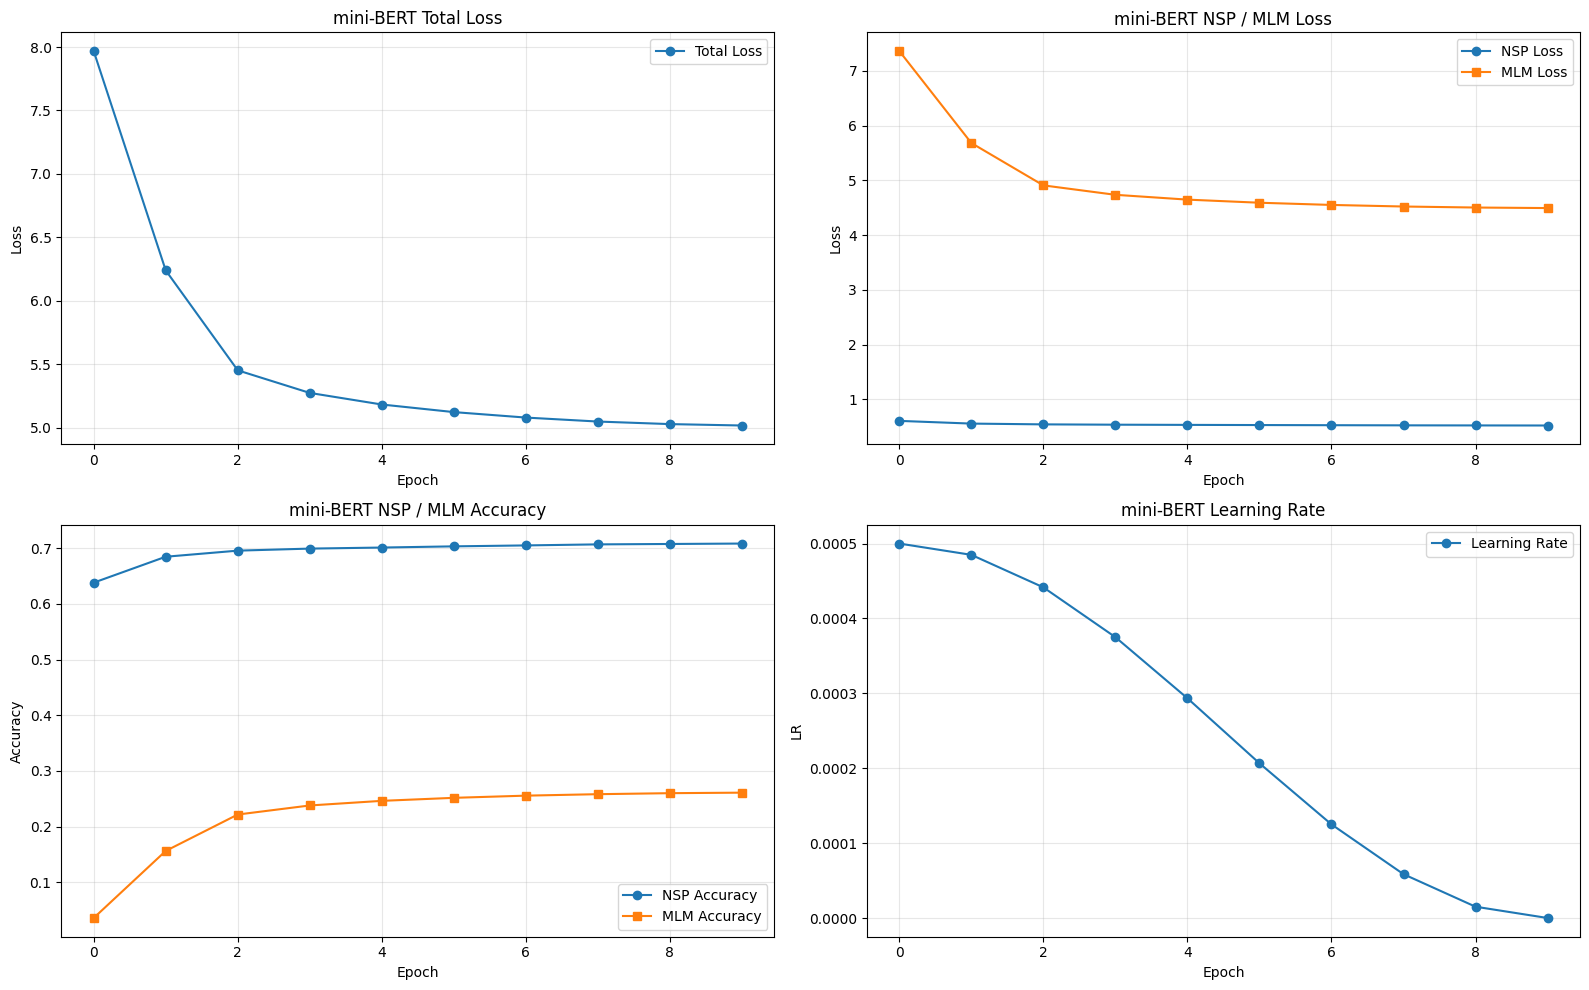

In [29]:
# ============================================================
# [STEP 10 - CELL 1] 학습 결과 시각화
# - 제출 루브릭에 맞게 NSP / MLM loss, accuracy 변화를 시각화합니다.
# ============================================================

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.plot(history["total_loss"], marker="o", label="Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("mini-BERT Total Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(history["nsp_loss"], marker="o", label="NSP Loss")
plt.plot(history["mlm_loss"], marker="s", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("mini-BERT NSP / MLM Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(history["nsp_acc"], marker="o", label="NSP Accuracy")
plt.plot(history["mlm_acc"], marker="s", label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("mini-BERT NSP / MLM Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(history["lr"], marker="o", label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.title("mini-BERT Learning Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# [STEP 10 - CELL 2] 저장 파일 최종 확인
# - 학습 결과물이 mini_ 접두사로 잘 저장되었는지 확인합니다.
# ============================================================

saved_files = [
    SPM_MODEL_PATH,
    SPM_VOCAB_PATH,
    PRETRAIN_JSON_PATH,
    MEMMAP_INFO_PATH,
    MINI_CONFIG_PATH,
    MINI_HISTORY_PATH,
    MINI_FINAL_MODEL_PATH,
]

for path in saved_files:
    print(path, "->", os.path.exists(path))

print("\nepoch checkpoints:")
for epoch in range(1, EPOCHS + 1):
    ckpt = get_checkpoint_path(epoch)
    print(ckpt, "->", os.path.exists(ckpt))

models/mini_ko_8000.model -> True
models/mini_ko_8000.vocab -> True
data/mini_bert_pre_train.json -> True
data/mini_pretrain_memmap_info.json -> True
models/mini_bert_config.json -> True
models/mini_bert_history.json -> True
models/mini_bert_pre_train_final.pt -> True

epoch checkpoints:
models/mini_bert_pre_train_epoch_01.pt -> True
models/mini_bert_pre_train_epoch_02.pt -> True
models/mini_bert_pre_train_epoch_03.pt -> True
models/mini_bert_pre_train_epoch_04.pt -> True
models/mini_bert_pre_train_epoch_05.pt -> True
models/mini_bert_pre_train_epoch_06.pt -> True
models/mini_bert_pre_train_epoch_07.pt -> True
models/mini_bert_pre_train_epoch_08.pt -> True
models/mini_bert_pre_train_epoch_09.pt -> True
models/mini_bert_pre_train_epoch_10.pt -> True


In [31]:
# ============================================================
# [STEP 10 - CELL 3] 간단한 샘플 추론 확인
# - 학습된 mini-BERT가 실제로 출력값을 내는지 확인하는 점검 셀입니다.
# - NSP logits / MLM logits shape을 확인합니다.
# ============================================================

pre_train_model.eval()

with torch.no_grad():
    sample_enc = pre_train_inputs[0][:2].to(device)
    sample_seg = pre_train_inputs[1][:2].to(device)

    sample_nsp_logits, sample_mlm_logits = pre_train_model(sample_enc, sample_seg)

print("sample_nsp_logits shape:", sample_nsp_logits.shape)   # (bs, 2)
print("sample_mlm_logits shape:", sample_mlm_logits.shape)   # (bs, n_seq, n_vocab)

sample_nsp_logits shape: torch.Size([2, 2])
sample_mlm_logits shape: torch.Size([2, 128, 8000])
